# Traning Project: California house price prediction

- Part 1: Import data
- Part 2: Numpy implementation of regression model
    1. Normal Equation
    2. MSE
    3. Gradient Descent
- Part 3: sklearn regression model

## Quick Notes

### Part 2 Numpy implementation - summary

1. Always split data into 3 parts: train, validation, and test.
   Use validation inside the training loop for model/epoch tuning, and keep test for final evaluation only.

2. Always normalize the feature matrix at the beginning.
   This stabilizes Gradient Descent updates and helps prevent gradient explosion.

3. A full-rank matrix guarantees a unique global minimum for the training objective.
   Gradient Descent can still achieve slightly lower test MSE than the Normal Equation because training optimization and test generalization are different.


## Part 1: Import data

In [109]:
import numpy as np
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

In [110]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [111]:
X = data.data
y = data.target
print(X.shape, y.shape)

(20640, 8) (20640,)


In [112]:
# train test split
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.2)

## Part 2: Numpy implementation of regression model

### 2.1 Normal Equation

$$
w = \left(X^\top X\right)^{-1} X^\top y
$$

In [113]:
## Normalise feature matrix
def normalise_feature(X):
    return ((X - X.mean(axis=0)) / X.std(axis=0))

Xn_train = normalise_feature(X_train)
Xn_val = normalise_feature(X_val)
Xn_test = normalise_feature(X_test)

In [114]:
## Bias trick
Xbn_train = np.hstack([np.ones((Xn_train.shape[0], 1)), Xn_train])
Xbn_test = np.hstack([np.ones((Xn_test.shape[0], 1)), Xn_test])
Xbn_val = np.hstack([np.ones((Xn_val.shape[0], 1)), Xn_val])

Xbn_train.shape

(13209, 9)

In [115]:
## Implementing normal equation
XtX = Xbn_train.T @ Xbn_train

## Check if the matrix is full rank (invertible)
print(XtX.shape[0])
print(np.linalg.matrix_rank(XtX))

9
9


In [116]:
# Optimal weighting 
w_neq = (np.linalg.inv(XtX) @ Xbn_train.T) @ y_train
w_neq

array([ 2.07111494,  0.82539932,  0.11173413, -0.25082548,  0.27576601,
       -0.00875531, -0.04072162, -0.90125111, -0.87170542])

### 2.2 Mean Squared Error (MSE)

$$
\mathrm{MSE} = \frac{1}{m}\sum_{i=1}^{m}\left(y_i - \hat{y}_i\right)^2
$$


In [117]:
# Testing
y_neq = Xbn_test @ w_neq

def mse(y1, y2):
    return np.mean((y1 - y2) ** 2)

MSE_neq = mse(y_test, y_neq)

print(f"MSE: {MSE_neq}")


MSE: 0.4887137397793395


### 2.3 Gradient Descent

The weight update rule is:

$$
\mathbf{w}_{(t+1)} \leftarrow \mathbf{w}_{(t)} - \alpha \, \nabla_{\mathbf{w}} L \Big|_{\mathbf{w}=\mathbf{w}_{(t)}}
$$

where 

$$
L(\mathbf{w})=\frac{1}{2}\sum_{i=1}^{m}\left(y^{(i)}-\mathbf{w}^{\top}\mathbf{x}^{(i)}\right)^2
=\frac{1}{2}\left\|\mathbf{y}-\mathbf{X}\mathbf{w}\right\|_2^2, \qquad \nabla_{\mathbf{w}}L=\mathbf{X}^{\top}\left(\mathbf{X}\mathbf{w}-\mathbf{y}\right)

$$





In [119]:
def grad_L(w):
    return (2/Xbn_train.shape[0])*(Xbn_train.T @ (Xbn_train @ w - y_train))

In [127]:
import matplotlib.pyplot as plt

lr = 0.1
epoch = 300
w_gd = np.random.rand(Xbn_train.shape[1])
mse_record = []
boundary = None

for i in range(epoch):
    w_cur = w_gd - lr * grad_L(w_gd)
    g = grad_L(w_gd)
    
    w_gd = w_cur
    y_gd = Xbn_val @ w_gd
    MSE_gd_val = mse(y_gd, y_val)
    
    print(f"Epoch {i+1} | MSE: {MSE_gd_val}") 
    mse_record.append(MSE_gd_val)

Epoch 1 | MSE: 5.30173837966181
Epoch 2 | MSE: 3.471112943999359
Epoch 3 | MSE: 2.4319144979476115
Epoch 4 | MSE: 1.8106809701846354
Epoch 5 | MSE: 1.425222690816646
Epoch 6 | MSE: 1.1796302261538434
Epoch 7 | MSE: 1.020003610114056
Epoch 8 | MSE: 0.9145007032915798
Epoch 9 | MSE: 0.8436386913826508
Epoch 10 | MSE: 0.7952128464958506
Epoch 11 | MSE: 0.7614565648067149
Epoch 12 | MSE: 0.7373734243361905
Epoch 13 | MSE: 0.7197228870357233
Epoch 14 | MSE: 0.7063890310209646
Epoch 15 | MSE: 0.6959816751537495
Epoch 16 | MSE: 0.6875817945422342
Epoch 17 | MSE: 0.680577877228061
Epoch 18 | MSE: 0.6745601623587744
Epoch 19 | MSE: 0.6692519663616492
Epoch 20 | MSE: 0.6644648923087736
Epoch 21 | MSE: 0.6600694826767992
Epoch 22 | MSE: 0.6559758962589411
Epoch 23 | MSE: 0.6521211167011735
Epoch 24 | MSE: 0.6484604344727914
Epoch 25 | MSE: 0.6449617374794382
Epoch 26 | MSE: 0.6416016569464712
Epoch 27 | MSE: 0.6383629457473958
Epoch 28 | MSE: 0.6352326805897831
Epoch 29 | MSE: 0.6322010187464048


In [128]:
y_gd = Xbn_test @ w_gd
MSE_gd = mse(y_test, y_gd)

print(f"MSE GD: {MSE_gd} | MSE NEQ: {MSE_neq}")

MSE GD: 0.48847383980273473 | MSE NEQ: 0.4887137397793395


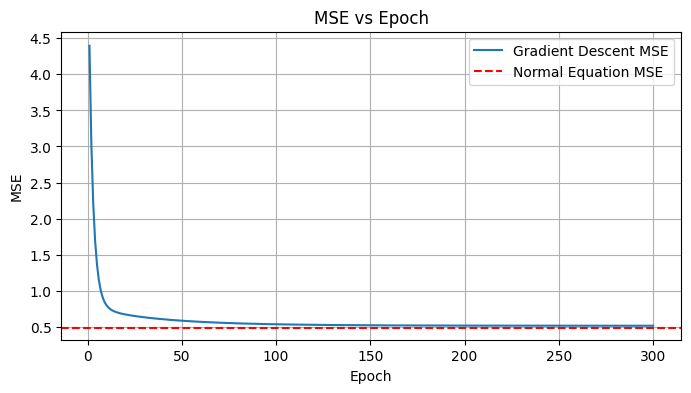

In [126]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epoch + 1), mse_record, label="Gradient Descent MSE")
plt.axhline(MSE_neq, color="r", linestyle="--", label="Normal Equation MSE")
if boundary:
    plt.axvline(boundary, color="b", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE vs Epoch")
plt.legend()
plt.grid(True)
plt.show()
